## 1. Imports and Data

Import libraries.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import het_arch

from arch import arch_model

# Load dataset

In [ ]:
TRAIN_PATH = "/Users/raresolteanu/Downloads/ts-forecasting/train.parquet"
TEST_PATH = "/Users/raresolteanu/Downloads/ts-forecasting/test.parquet"
RANDOM_STATE = 42 

df = pd.read_parquet(TRAIN_PATH)
df_test = pd.read_parquet(TEST_PATH)
horizons = sorted(df["horizon"].unique())

Horizons: [1, 3, 10, 25]


# Visualise it

In [4]:
df.head()

,id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,...,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
0,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,25,89,29,16.364093,7.464023,5.966933,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.551324,40.982572
1,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__1__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,1,89,53,2.858806,5.050617,15.906651,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.315583,150.075406
2,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__3__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,3,89,51,9.585452,1.076268,9.004147,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.362894,115.953552
3,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__10__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,10,89,44,8.840588,15.034634,4.170780,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.667023,64.573073
4,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__90,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,25,90,28,2.303825,7.696209,12.896100,...,-0.001622,-0.103809,-0.005135,NaN,-0.174660,2.738606,0.109204,1,-0.437398,41.948761


In [5]:
df_test.head()

,id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,...,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch
0,W2MW3G2L__495MGHFJ__PZ9S1Z4V__3__3647,W2MW3G2L,495MGHFJ,PZ9S1Z4V,3,3647,95,10.365266,3.209321,8.109339,...,-0.000832,-0.032241,-0.000830,-0.058961,-0.002774,-0.001480,-0.25646,1.665532,0.071324,2
1,W2MW3G2L__495MGHFJ__PZ9S1Z4V__10__3647,W2MW3G2L,495MGHFJ,PZ9S1Z4V,10,3647,88,2.571477,15.234848,16.505699,...,-0.000832,-0.032241,-0.000830,-0.058961,-0.002774,-0.001480,-0.25646,1.665532,0.071324,2
2,W2MW3G2L__495MGHFJ__PZ9S1Z4V__25__3647,W2MW3G2L,495MGHFJ,PZ9S1Z4V,25,3647,71,5.524709,6.931663,8.939537,...,-0.000832,-0.032241,-0.000830,-0.058961,-0.002774,-0.001480,-0.25646,1.665532,0.071324,2
3,W2MW3G2L__495MGHFJ__PZ9S1Z4V__1__3647,W2MW3G2L,495MGHFJ,PZ9S1Z4V,1,3647,97,10.293758,14.893660,9.435544,...,-0.000832,-0.032241,-0.000830,-0.058961,-0.002774,-0.001480,-0.25646,1.665532,0.071324,2
4,W2MW3G2L__495MGHFJ__PZ9S1Z4V__10__3648,W2MW3G2L,495MGHFJ,PZ9S1Z4V,10,3648,87,14.776194,7.701180,6.228968,...,-0.000844,-0.032988,-0.000841,-0.059835,-0.002838,-0.001501,-0.24224,1.671890,0.071100,2


In [6]:
print(horizons)

[1, 3, 10, 25]


## 2. Quick Visualization

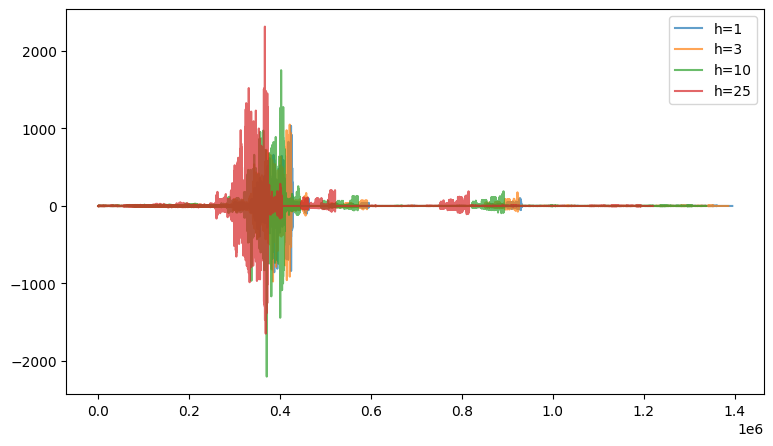

In [7]:
plt.figure(figsize=(9,5))
for h in horizons:
    series = df[df["horizon"] == h]["y_target"].dropna().reset_index(drop=True)
    plt.plot(series, label=f"h={h}", alpha= 0.7)
plt.legend()
plt.show()

## 3. Rolling Mean

This is the rolling mean window 

In [ ]:
windows = [5, 20, 50, 200, 500] 

For horizon = 25

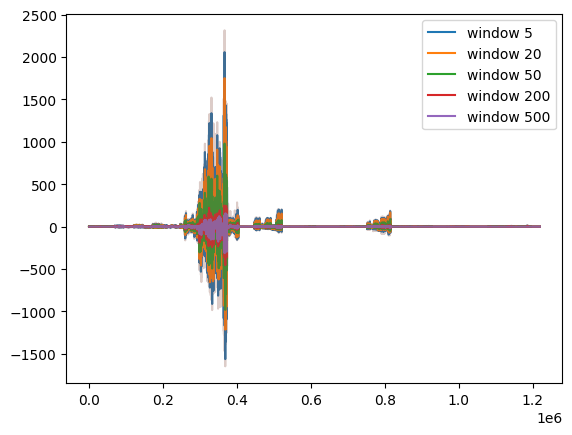

In [18]:
series = df[df["horizon"] == horizons[3]]["y_target"].dropna().reset_index(drop=True)

for w in windows:
    plt.plot(series.rolling(w).mean(), label=f"window {w}")
plt.plot(series, alpha=0.3)
plt.legend()
plt.show()

For horizon = 10

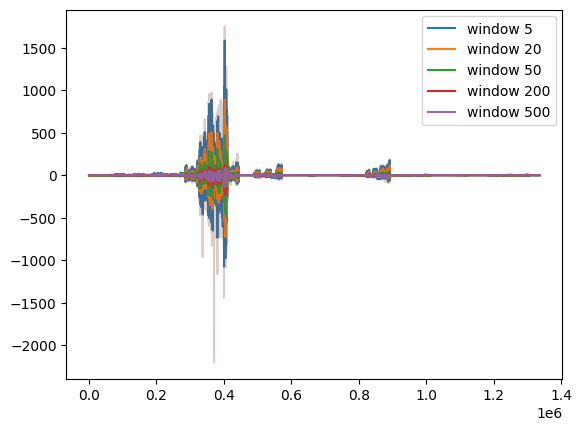

In [19]:
series = df[df["horizon"] == horizons[2]]["y_target"].dropna().reset_index(drop=True)

for w in windows:
    plt.plot(series.rolling(w).mean(), label=f"window {w}")
plt.plot(series, alpha=0.3)
plt.legend()
plt.show()

For horizon = 3

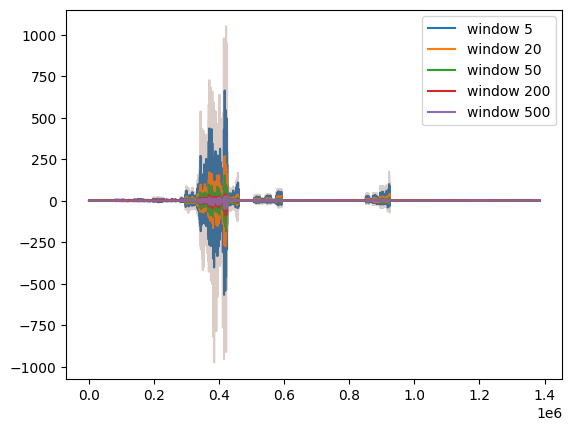

In [20]:
series = df[df["horizon"] == horizons[1]]["y_target"].dropna().reset_index(drop=True)

for w in windows:
    plt.plot(series.rolling(w).mean(), label=f"window {w}")
plt.plot(series, alpha=0.3)
plt.legend()
plt.show()

For horizon = 1

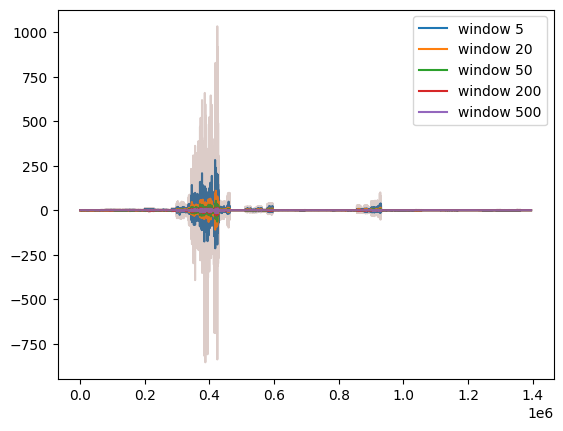

In [21]:
series = df[df["horizon"] == horizons[0]]["y_target"].dropna().reset_index(drop=True)

for w in windows:
    plt.plot(series.rolling(w).mean(), label=f"window {w}")
plt.plot(series, alpha=0.3)
plt.legend()
plt.show()

The table with different rolling windows and different horizons and their correlation with the true data and RMSE and their average correlation and RMSE

In [22]:
rows = []

for h in horizons: 
    series = df[df["horizon"] == h]["y_target"].dropna().reset_index(drop=True)

    for w in windows:
        roll = series.rolling(w).mean().dropna().reset_index(drop=True)
        original = series.iloc[w-1:].reset_index(drop=True)

        corr = original.corr(roll)
        rmse = np.sqrt(np.mean((original - roll) ** 2))

        rows.append({
            "horizon": h,
            "window": w,
            "correlation_with_series": corr,
            "rmse_vs_series": rmse
        })

similarity_all_horizons = pd.DataFrame(rows)

print("Results for each horizon with each window:")
display(similarity_all_horizons.round(4))

average_similarity = (
    similarity_all_horizons
    .groupby("window", as_index=False)[["correlation_with_series", "rmse_vs_series"]]
    .mean()
)

print("Average over the 4 horizons:")
display(average_similarity.round(4))


Results for each horizon with each window:


,horizon,window,correlation_with_series,rmse_vs_series
0,1,5,0.4463,10.4703
1,1,20,0.2388,11.3620
2,1,50,0.1602,11.5489
3,1,200,0.0859,11.6577
4,1,500,0.0647,11.6777
5,3,5,0.5617,16.1891
6,3,20,0.2970,18.5726
7,3,50,0.2128,18.9543
8,3,200,0.1235,19.2350
9,3,500,0.0978,19.2825


Average over the 4 horizons:


,window,correlation_with_series,rmse_vs_series
0,5,0.7000,15.6886
1,20,0.4343,24.3249
2,50,0.2958,27.5790
3,200,0.1699,28.8890
4,500,0.1356,29.0570


## 4. AR + ARCH Test

It is only the first 10000 rows, since the data is too big to be run on a Mac CPU, also they are the first ones not the random ones because the data is based on time series and the order matters

In [40]:
results = {}

for h in horizons:
    series = (
        df[df["horizon"] == h]["y_target"]
        .dropna()
        .reset_index(drop=True)
        .iloc[:10000]
    )

    model = AutoReg(series, lags=1).fit()
    res = model.resid

    pval = het_arch(res)[1]
    print(f"h = {h}, ARCH p-value = {pval:.10e}")

    results[h] = {
        "series": series,
        "residuals": res,
        "arch_pvalue": pval
    }

h = 1, ARCH p-value = 2.3610799772e-142
h = 3, ARCH p-value = 0.0000000000e+00
h = 10, ARCH p-value = 4.3493916296e-121
h = 25, ARCH p-value = 4.4926920790e-151


# 5. ACF 
We plot it to to see if there is heteroscedasticity within the data, namely if the variability of a dependent variable is unequal across the range of values of an independent variable. If the data within the confidence interval, the we can use ARCH famility models

h = 1, ARCH p-value = 2.361e-142


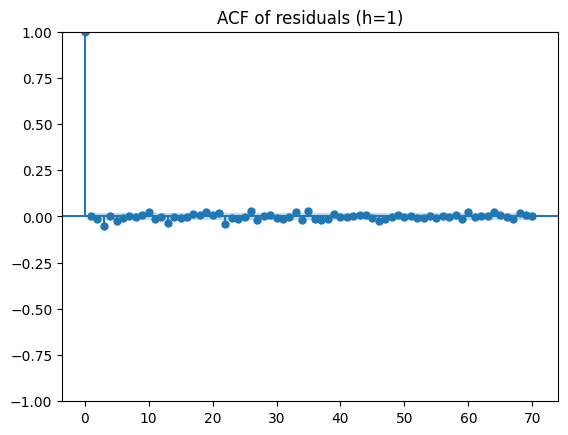

h = 3, ARCH p-value = 0.000e+00


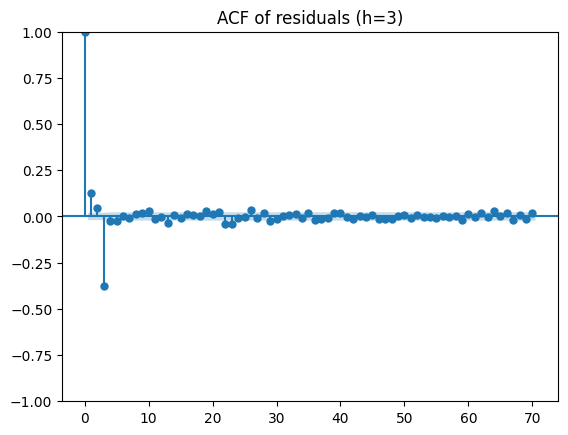

h = 10, ARCH p-value = 4.349e-121


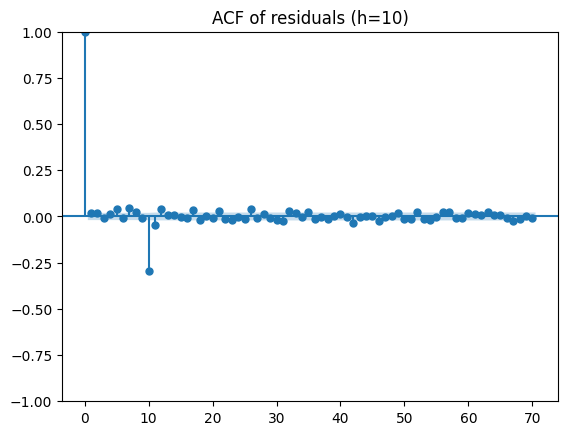

h = 25, ARCH p-value = 4.493e-151


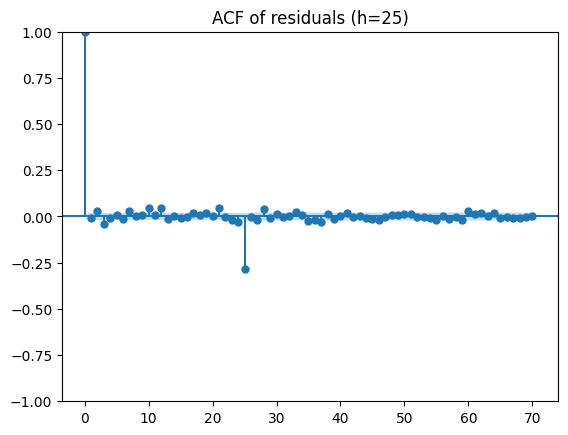

In [26]:
results = {}

for i, h in enumerate(horizons):
    series = (
        df[df["horizon"] == h]["y_target"]
        .dropna()
        .reset_index(drop=True)
        .iloc[:10000]
    )

    model = AutoReg(series, lags=1).fit()
    res = model.resid

    pval = het_arch(res)[1]
    print(f"h = {h}, ARCH p-value = {pval:.3e}")

    if i < 4:
        plot_acf(res, lags=70)
        plt.title(f"ACF of residuals (h={h})")
        plt.show()
        plt.close()

    results[h] = {
        "series": series,
        "residuals": res,
        "arch_pvalue": pval
    }

## 6. GARCH

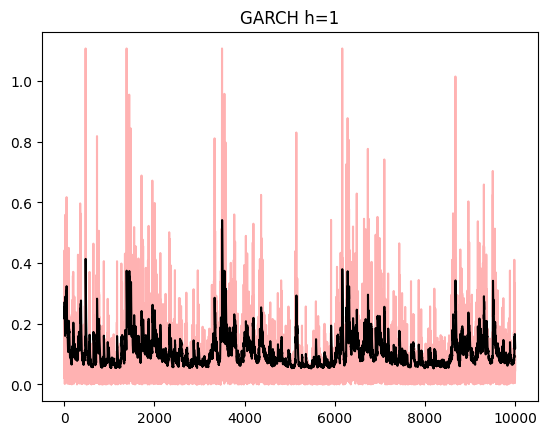

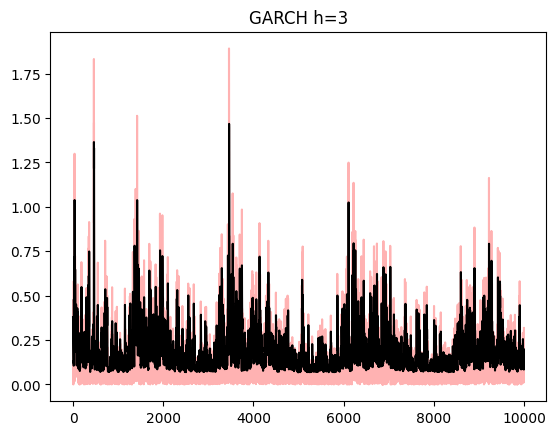

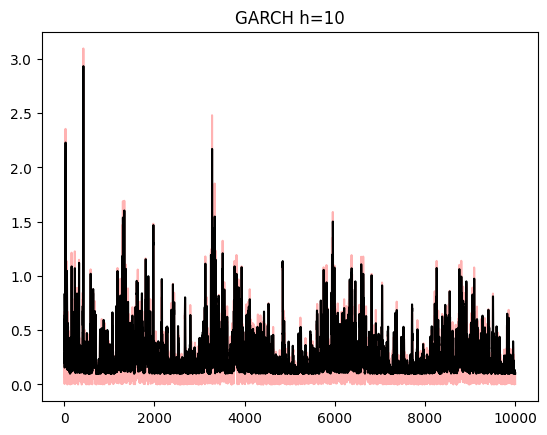

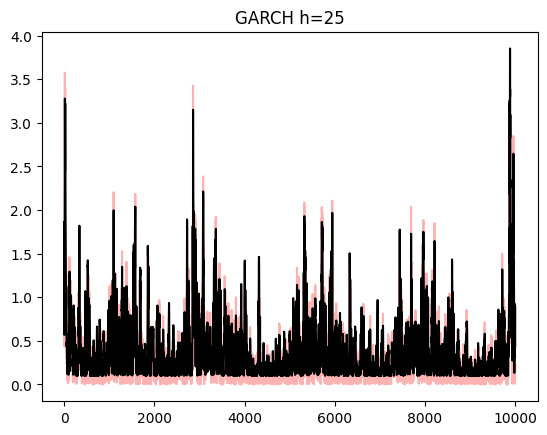

In [30]:
for h in horizons:
    series = results[h]["series"]
    g = arch_model(series, vol="GARCH", p=1, q=1).fit(disp="off")
    v = g.conditional_volatility

    plt.plot(series.abs(), alpha=0.3, color= 'red')
    plt.plot(v, color='black')
    plt.title(f"GARCH h={h}")
    plt.show()

    results[h]["garch"] = g
    results[h]["garch_vol"] = v

## 7. Persistence

#### Persistence


Persistence = $\alpha + \beta$

- If $\alpha + \beta < 1$: stationary (mean-reverting volatility)  
- If $\alpha + \beta \approx 1$: highly persistent volatility  
- If $\alpha + \beta > 1$: explosive (non-stationary)

In [24]:
for h in horizons:
    g = results[h]["garch"]
    p = g.params["alpha[1]"] + g.params["beta[1]"]
    print("h=", h, "Persistence:", p)

h= 1 Persistence: 0.9800000020103656
h= 3 Persistence: 0.9800000058688209
h= 10 Persistence: 0.9790143948518663
h= 25 Persistence: 0.9799948361600745


## 8. FIGARCH

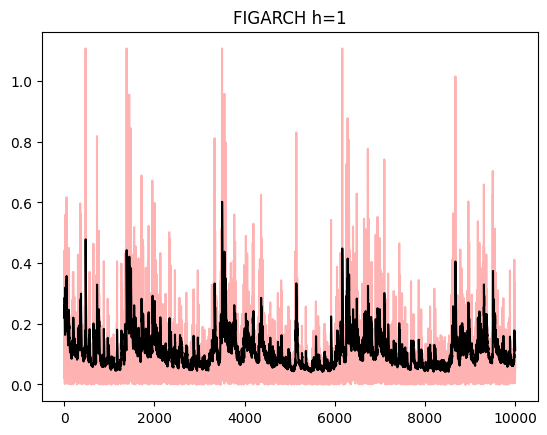

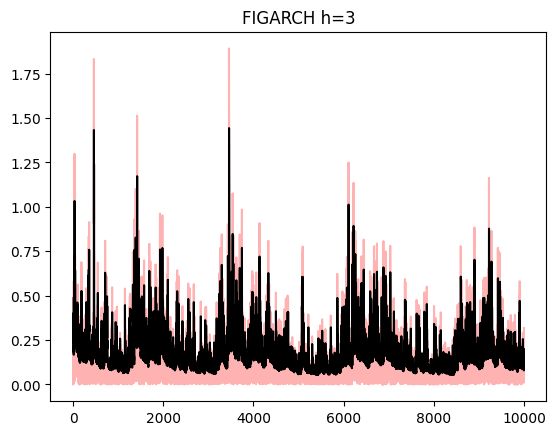

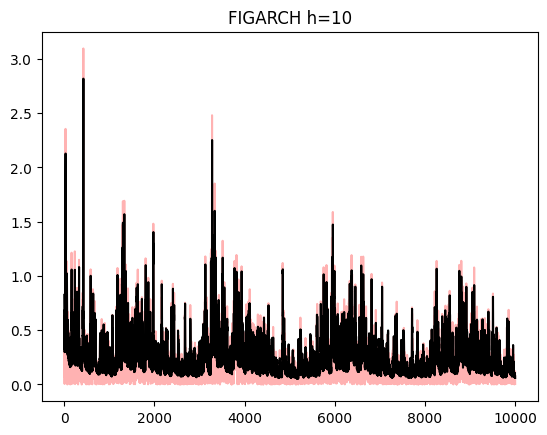

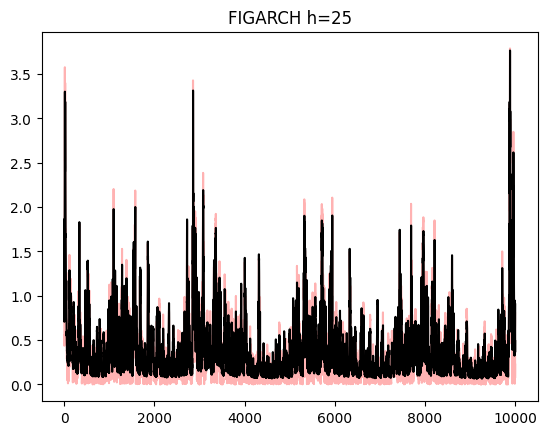

In [32]:
for h in horizons:
    series = results[h]["series"]
    f = arch_model(series, vol="FIGARCH", p=1, q=1).fit(disp="off")
    v = f.conditional_volatility

    plt.plot(series.abs(), alpha=0.3, color='red')
    plt.plot(v , color = 'black')
    plt.title(f"FIGARCH h={h}")
    plt.show()

    results[h]["figarch_vol"] = v

## 9. HARCH

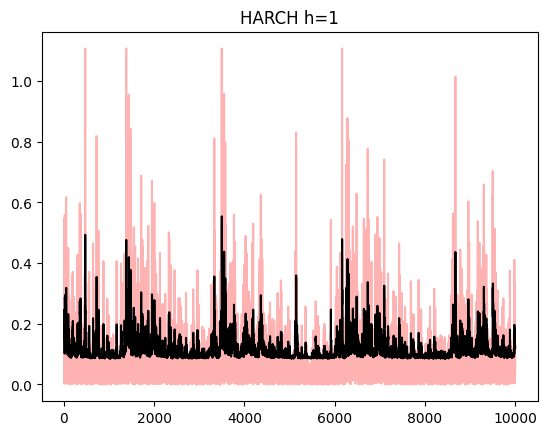

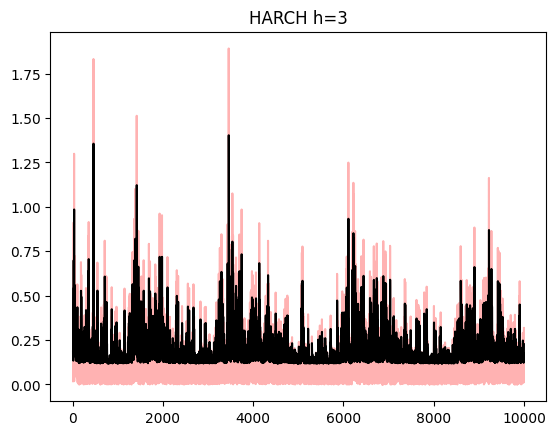

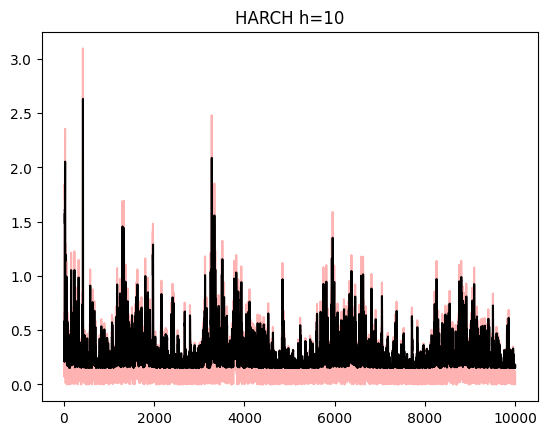

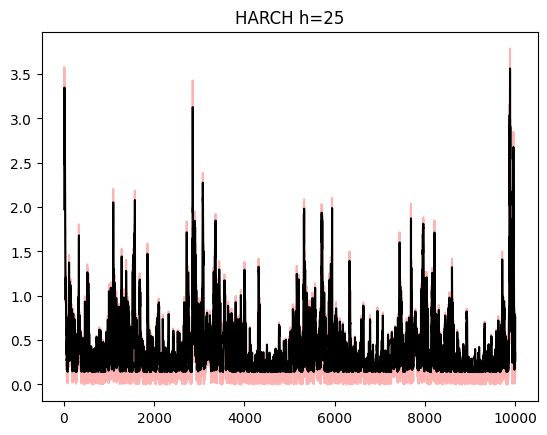

In [34]:
harch_next_vols = []

for h in horizons:
    s = results[h]["series"]
    sq = s**2

    df_h = pd.DataFrame({
        "y": sq,
        "r1": sq.rolling(1).mean().shift(1),
        "r5": sq.rolling(5).mean().shift(1),
        "r10": sq.rolling(10).mean().shift(1)
    }).dropna()

    X = sm.add_constant(df_h[["r1","r5","r10"]])
    y = df_h["y"]

    m = sm.OLS(y,X).fit()
    p = np.sqrt(m.predict(X))
    
    plt.plot(np.sqrt(y), alpha = 0.3, color = 'red')
    plt.plot(p , color = 'black')
    plt.title(f"HARCH h={h}")
    plt.show()

    results[h]["harch_pred"] = p
    results[h]["harch_real"] = np.sqrt(y)

## 10. RMSE Comparison

In [35]:
for h in horizons:
    real = results[h]["series"].abs()
    g = results[h]["garch_vol"]
    f = results[h]["figarch_vol"]

    g_rmse = np.sqrt(np.mean((g - real[-len(g):])**2))
    f_rmse = np.sqrt(np.mean((f - real[-len(f):])**2))

    hp = results[h]["harch_pred"]
    hr = results[h]["harch_real"]

    h_rmse = np.sqrt(np.mean((hp - hr)**2))

    print(h, g_rmse, f_rmse, h_rmse)

1 0.0914815423613338 0.09252709267306669 0.09274525267329589
3 0.13593532008506404 0.1256101183409334 0.12791855269750504
10 0.15260001263370543 0.14545213841144752 0.14669926978962416
25 0.1815980905973304 0.17843930450663273 0.15513114769557618


## 11. Forecast

This is for horison 1 GARCH

In [36]:
h = 1
garch_res = results[h]["garch"]

forecast = garch_res.forecast(horizon=1)
vol = np.sqrt(forecast.variance.iloc[-1, 0])

print("Next volatility:", vol)

Next volatility: 0.11570242232078654


This is for all 4 GARCH

In [37]:
for h in horizons:
    garch_res = results[h]["garch"]

    forecast = garch_res.forecast(horizon=1)
    vol = np.sqrt(forecast.variance.iloc[-1, 0])

    print(f"h = {h}, next volatility = {vol:.6f}")

h = 1, next volatility = 0.115702
h = 3, next volatility = 0.244626
h = 10, next volatility = 0.109672
h = 25, next volatility = 0.250529


Fitting again FIGARCH for all 4 horizons 

In [40]:
for h in horizons:
    series = results[h]["series"]

    figarch_model = arch_model(series, vol="FIGARCH", p=1, q=1)
    figarch_res = figarch_model.fit(disp="off")

    results[h]["figarch"] = figarch_res
    results[h]["figarch_vol"] = figarch_res.conditional_volatility

    print(f"h = {h} FIGARCH fitted")

h = 1 FIGARCH fitted
h = 3 FIGARCH fitted
h = 10 FIGARCH fitted
h = 25 FIGARCH fitted


Its forecast

In [41]:
figarch_next_vols = []

for h in horizons:
    fig = results[h]["figarch"]
    forecast = fig.forecast(horizon=1)
    vol = np.sqrt(forecast.variance.iloc[-1, 0])

    figarch_next_vols.append(vol)
    print(f"h = {h}, FIGARCH next volatility = {vol:.6f}")

h = 1, FIGARCH next volatility = 0.105650
h = 3, FIGARCH next volatility = 0.243044
h = 10, FIGARCH next volatility = 0.074016
h = 25, FIGARCH next volatility = 0.294782


Fitting HARCH and see its forecast 

In [42]:
harch_next_vols = []

for h in horizons:
    s = results[h]["series"]
    sq = s**2

    df_h = pd.DataFrame({
        "y": sq,
        "r1": sq.rolling(1).mean().shift(1),
        "r5": sq.rolling(5).mean().shift(1),
        "r10": sq.rolling(10).mean().shift(1)
    }).dropna()

    X = sm.add_constant(df_h[["r1","r5","r10"]])
    y = df_h["y"]

    m = sm.OLS(y, X).fit()

    last_x = X.iloc[[-1]]
    next_var = m.predict(last_x).iloc[0]
    next_vol = np.sqrt(next_var)

    harch_next_vols.append(next_vol)
    print(f"h = {h}, HARCH next volatility = {next_vol:.6f}")

h = 1, HARCH next volatility = 0.123642
h = 3, HARCH next volatility = 0.226969
h = 10, HARCH next volatility = 0.159676
h = 25, HARCH next volatility = 0.360720


# 12. Trying other models 

The ARCH and GARCH are put there for baselines

In [47]:
all_comparisons = []

for h in horizons:
    resid = results[h]["residuals"]
    comparison = []

    for name, params in candidate_models:
        try:
            model = arch_model(resid, mean="Zero", **params)
            res = model.fit(disp="off")

            cond_vol = res.conditional_volatility
            real = pd.Series(resid).abs().iloc[-len(cond_vol):]
            rmse = np.sqrt(np.mean((cond_vol - real) ** 2))

            comparison.append({
                "horizon": h,
                "model": name,
                "AIC": res.aic,
                "BIC": res.bic,
                "RMSE": rmse,
                "converged": True
            })

            print(f"h={h} | {name} fitted")

        except Exception as e:
            comparison.append({
                "horizon": h,
                "model": name,
                "AIC": np.nan,
                "BIC": np.nan,
                "RMSE": np.nan,
                "converged": False
            })

            print(f"h={h} | {name} failed: {e}")

    comparison_df = pd.DataFrame(comparison).sort_values("AIC")
    results[h]["comparison_df"] = comparison_df
    all_comparisons.append(comparison_df)

final_comparison_df = pd.concat(all_comparisons, ignore_index=True)
final_comparison_df

h=1 | ARCH(1) fitted
h=1 | GARCH(1,1) fitted
h=1 | GARCH(2,1) fitted
h=1 | GARCH(1,2) fitted
h=1 | EGARCH(1,1) fitted
h=3 | ARCH(1) fitted
h=3 | GARCH(1,1) fitted
h=3 | GARCH(2,1) fitted
h=3 | GARCH(1,2) fitted
h=3 | EGARCH(1,1) fitted
h=10 | ARCH(1) fitted
h=10 | GARCH(1,1) fitted
h=10 | GARCH(2,1) fitted
h=10 | GARCH(1,2) fitted
h=10 | EGARCH(1,1) fitted
h=25 | ARCH(1) fitted
h=25 | GARCH(1,1) fitted
h=25 | GARCH(2,1) fitted
h=25 | GARCH(1,2) fitted
h=25 | EGARCH(1,1) fitted


,horizon,model,AIC,BIC,RMSE,converged
0,1,"EGARCH(1,1)",-18013.523300,-17991.892579,0.092047,True
1,1,"GARCH(1,1)",-17731.861643,-17710.230922,0.092075,True
2,1,"GARCH(1,2)",-17728.102073,-17699.261111,0.092292,True
3,1,"GARCH(2,1)",-17639.087870,-17610.246909,0.092543,True
4,1,ARCH(1),-15488.317655,-15473.897174,0.100650,True
5,3,"EGARCH(1,1)",-13008.905606,-12987.274885,0.115259,True
6,3,"GARCH(1,2)",-12939.334842,-12910.493881,0.117440,True
7,3,"GARCH(1,1)",-12932.596948,-12910.966227,0.117743,True
8,3,"GARCH(2,1)",-12820.878749,-12792.037788,0.115405,True
9,3,ARCH(1),-10002.941006,-9988.520525,0.127063,True


# 13. Leverage Effect

In [48]:
for h in horizons:
    resid = results[h]["residuals"]

    gjr = arch_model(resid, mean="Zero", vol="GARCH", p=1, o=1, q=1)
    gjr_res = gjr.fit(disp="off")

    gamma = gjr_res.params["gamma[1]"]
    pval = gjr_res.pvalues["gamma[1]"]

    print(f"h = {h}")
    print(f"gamma = {gamma:.6f}")
    print(f"p-value = {pval:.6e}")

    if gamma > 0 and pval < 0.05:
        print("Leverage effect detected\n")
    else:
        print("No strong leverage effect\n")

h = 1
gamma = 0.010000
p-value = 5.593004e-01
No strong leverage effect

h = 3
gamma = -0.030841
p-value = 9.672010e-02
No strong leverage effect

h = 10
gamma = 0.010000
p-value = 6.857324e-01
No strong leverage effect

h = 25
gamma = 0.010000
p-value = 8.387186e-01
No strong leverage effect



In [49]:
df.head()

,id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,...,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
0,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,25,89,29,16.364093,7.464023,5.966933,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.551324,40.982572
1,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__1__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,1,89,53,2.858806,5.050617,15.906651,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.315583,150.075406
2,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__3__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,3,89,51,9.585452,1.076268,9.004147,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.362894,115.953552
3,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__10__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,10,89,44,8.840588,15.034634,4.170780,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.667023,64.573073
4,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__90,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,25,90,28,2.303825,7.696209,12.896100,...,-0.001622,-0.103809,-0.005135,NaN,-0.174660,2.738606,0.109204,1,-0.437398,41.948761


# 14 Subcode with ARCH effects

In [50]:
subcode_scores = []

for sub in df["sub_code"].unique()[:20]:  #  I limit to first 20 for speed, since I have Mac CPU
    series = (
        df[df["sub_code"] == sub]["y_target"]
        .dropna()
        .reset_index(drop=True)
        .iloc[:10000] # I limit for the same reason to firs 10000 rows 
    )

    if len(series) < 100:
        continue

    model = AutoReg(series, lags=1).fit()
    res = model.resid

    pval = het_arch(res)[1]
    variance = np.var(series)

    subcode_scores.append({
        "subcode": sub,
        "arch_pvalue": pval,
        "variance": variance
    })

sub_df = pd.DataFrame(subcode_scores)

best_subcodes = sub_df.sort_values("variance", ascending=False).head(10)
best_subcodes

,subcode,arch_pvalue,variance
3,P9ZIZD7U,0.0,164.285426
16,WK6PHRP2,0.0,133.738954
13,HLMZ8R13,0.0,87.085712
17,YZ5BVW8B,0.0,80.707221
12,STALY73S,0.0,76.068436
4,6TA07NOO,0.0,65.587917
18,IPNRRGWZ,0.0,60.149403
5,VYQLNVSJ,0.0,28.496219
8,YGQ34KOD,0.0,25.347620
6,RZZAJL41,0.0,19.561303


/var/folders/z9/yljky7zj70z5lp2gz0k3bdq00000gn/T/ipykernel_94098/137753374.py:4: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch = arch_model(resid, mean="Zero", vol="GARCH", p=1, q=1).fit(disp="off")


Selected subcode: P9ZIZD7U

Horizon = 1


/var/folders/z9/yljky7zj70z5lp2gz0k3bdq00000gn/T/ipykernel_94098/137753374.py:24: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch = arch_model(resid, mean="Zero", vol="GARCH", p=1, q=1).fit(disp="off")


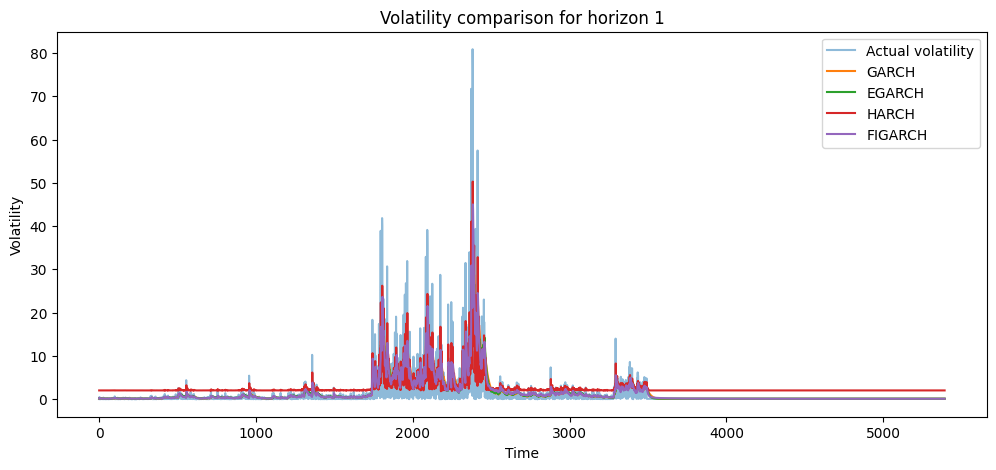


Horizon = 3


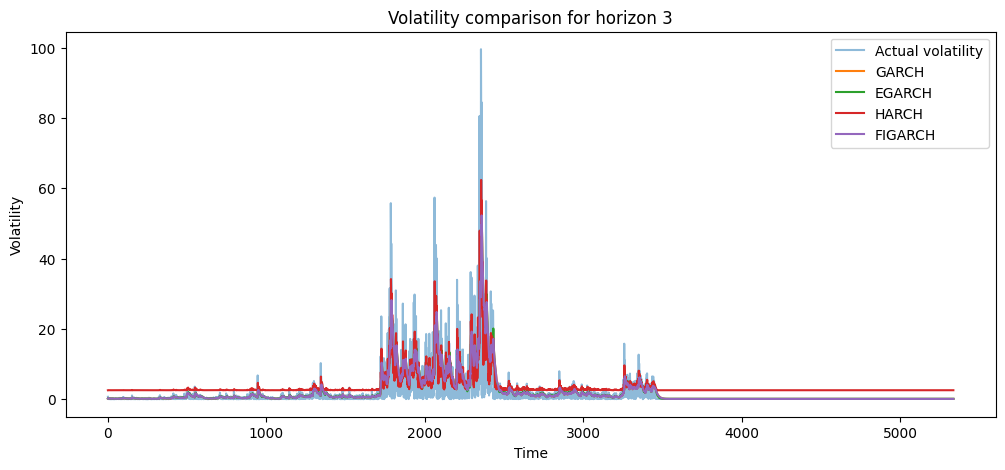


Horizon = 10


/var/folders/z9/yljky7zj70z5lp2gz0k3bdq00000gn/T/ipykernel_94098/137753374.py:24: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch = arch_model(resid, mean="Zero", vol="GARCH", p=1, q=1).fit(disp="off")


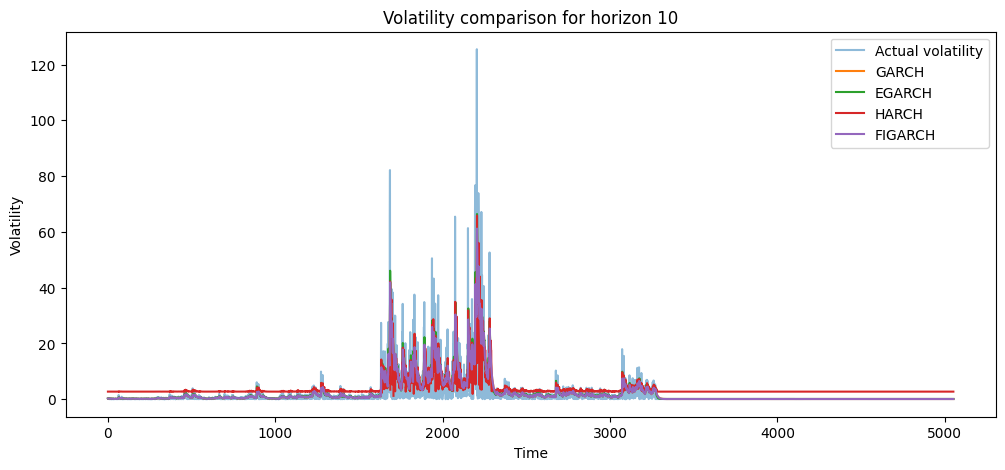


Horizon = 25


/var/folders/z9/yljky7zj70z5lp2gz0k3bdq00000gn/T/ipykernel_94098/137753374.py:24: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch = arch_model(resid, mean="Zero", vol="GARCH", p=1, q=1).fit(disp="off")


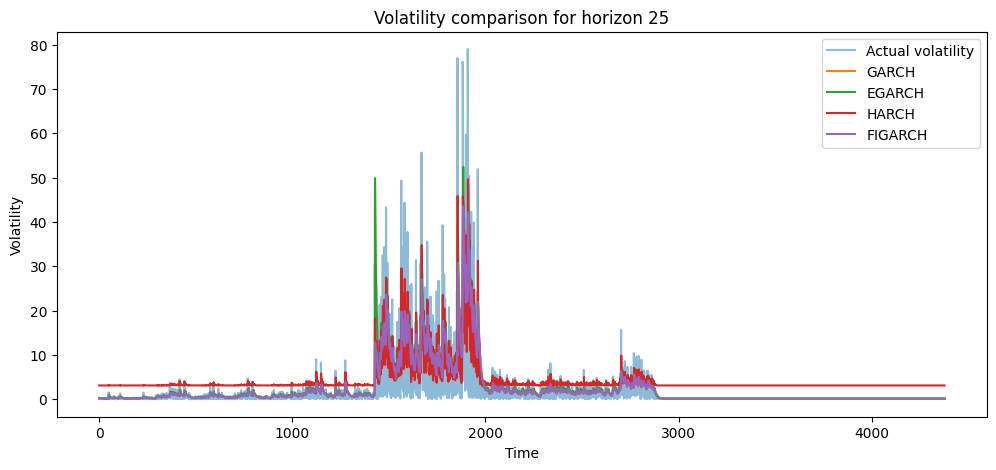

In [ ]:
best_subcode = best_subcodes.iloc[0]["subcode"]
print("Selected subcode:", best_subcode)

for h in horizons:
    print("\nHorizon =", h)

    series = df[(df["sub_code"] == best_subcode) & (df["horizon"] == h)]["y_target"].dropna().reset_index(drop=True).iloc[:10000]

    if len(series) < 50:
        print("Too few observations, skipped")
        continue

    # AR(1) mean model
    ar_model = AutoReg(series, lags=1).fit()
    resid = pd.Series(ar_model.resid).reset_index(drop=True)
    actual_vol = resid.abs()

    # GARCH
    garch = arch_model(resid, mean="Zero", vol="GARCH", p=1, q=1).fit(disp="off")
    garch_vol = pd.Series(garch.conditional_volatility).reset_index(drop=True)

    # EGARCH
    egarch = arch_model(resid, mean="Zero", vol="EGARCH", p=1, q=1).fit(disp="off")
    egarch_vol = pd.Series(egarch.conditional_volatility).reset_index(drop=True)

    # FIGARCH
    figarch_vol = None
    try:
        figarch = arch_model(resid, mean="Zero", vol="FIGARCH", p=1, q=1).fit(disp="off")
        figarch_vol = pd.Series(figarch.conditional_volatility).reset_index(drop=True)
    except:
        print("FIGARCH failed")

    # HARCH
    sq = resid ** 2
    df_harch = pd.DataFrame({
        "y": sq,
        "r1": sq.rolling(1).mean().shift(1),
        "r5": sq.rolling(5).mean().shift(1),
        "r10": sq.rolling(10).mean().shift(1)
    }).dropna()

    X = sm.add_constant(df_harch[["r1", "r5", "r10"]])
    y = df_harch["y"]

    harch = sm.OLS(y, X).fit()
    harch_vol = pd.Series(np.sqrt(harch.predict(X))).reset_index(drop=True)

    # make lengths equal
    min_len = min(len(actual_vol), len(garch_vol), len(egarch_vol), len(harch_vol))
    if figarch_vol is not None:
        min_len = min(min_len, len(figarch_vol))

    actual_plot = actual_vol.iloc[-min_len:].reset_index(drop=True)
    garch_plot = garch_vol.iloc[-min_len:].reset_index(drop=True)
    egarch_plot = egarch_vol.iloc[-min_len:].reset_index(drop=True)
    harch_plot = harch_vol.iloc[-min_len:].reset_index(drop=True)

    plt.figure(figsize=(12, 5))
    plt.plot(actual_plot, label="Actual volatility", alpha=0.5)
    plt.plot(garch_plot, label="GARCH")
    plt.plot(egarch_plot, label="EGARCH")
    plt.plot(harch_plot, label="HARCH")

    if figarch_vol is not None:
        figarch_plot = figarch_vol.iloc[-min_len:].reset_index(drop=True)
        plt.plot(figarch_plot, label="FIGARCH")

    plt.title(f"Volatility comparison for horizon {h}")
    plt.xlabel("Time")
    plt.ylabel("Volatility")
    plt.legend()
    plt.show()

In [ ]:
rows = []

best_subcode = best_subcodes.iloc[0]["subcode"] 
horizons = [1, 3, 10, 25]

models = [
    ("GARCH", "GARCH", {"p": 1, "q": 1}),
    ("EGARCH", "EGARCH", {"p": 1, "q": 1}),
    ("FIGARCH", "FIGARCH", {"p": 1, "q": 1}),
    ("HARCH", "HARCH", {"p": [1, 5, 10]})
]

for h in horizons:
    series = (
        df[(df["sub_code"] == best_subcode) & (df["horizon"] == h)]
        .sort_values("ts_index")["y_target"]
        .dropna()
        .reset_index(drop=True)
    )

    if len(series) < 50:
        continue

    ar_res = AutoReg(series, lags=1, old_names=False).fit()
    resid = pd.Series(ar_res.resid).dropna().reset_index(drop=True)
    actual_vol = resid.abs()

    for model_name, vol_name, kwargs in models:
        try:
            res = arch_model(
                resid,
                mean="Zero",
                vol=vol_name,
                dist="t",
                rescale=True,
                **kwargs
            ).fit(disp="off")

            fitted_vol = pd.Series(res.conditional_volatility).dropna().reset_index(drop=True)

            n = min(len(actual_vol), len(fitted_vol))
            rmse = np.sqrt(np.mean((actual_vol.iloc[-n:] - fitted_vol.iloc[-n:])**2))

            rows.append({
                "subcode": best_subcode,
                "horizon": h,
                "model": model_name,
                "AIC": res.aic,
                "BIC": res.bic,
                "LogLik": res.loglikelihood,
                "RMSE": rmse
            })
        except:
            pass

results_table = pd.DataFrame(rows)
display(results_table.round(4))

,subcode,horizon,model,AIC,BIC,LogLik,RMSE
0,P9ZIZD7U,1,GARCH,13757.5780,13783.9561,-6874.7890,3.5773
1,P9ZIZD7U,1,EGARCH,13364.3901,13390.7682,-6678.1950,3.7423
2,P9ZIZD7U,1,FIGARCH,13703.5812,13736.5539,-6846.7906,4.9279
3,P9ZIZD7U,1,HARCH,13577.2554,13610.2280,-6783.6277,3.7256
4,P9ZIZD7U,3,GARCH,21029.8693,21056.2057,-10510.9346,6.3852
5,P9ZIZD7U,3,EGARCH,20919.6230,20945.9594,-10455.8115,6.9551
6,P9ZIZD7U,3,FIGARCH,21042.4381,21075.3586,-10516.2190,7.5945
7,P9ZIZD7U,3,HARCH,21011.2506,21044.1711,-10500.6253,6.4333
8,P9ZIZD7U,10,GARCH,26068.6504,26094.7685,-13030.3252,10.9471
9,P9ZIZD7U,10,EGARCH,25835.7387,25861.8567,-12913.8693,11.2974
